# Project 1 — Who Scores More Than Expected? (Residual Analysis)

**The interesting question:** *"Given a player's shot diet — how many FGA, 3PA, and FTA they took — how many points **should** they have scored?  And who consistently beats that expectation?"*

Predicting `PTS` directly from `FGA` is boring — more shots obviously means more points.
The **residual** (actual − predicted) is where the insight lives. A player with a large positive residual scored **more points than a league-average player would have on the same shot diet** — i.e., they're an efficient scorer.

**What makes this a real portfolio project**
- We use an ML model as a **measurement tool**, not a prediction toy. That's how professional analytics works.
- The output is a **ranked leaderboard** of NBA players by "points above expected" — something you can defend at an interview.
- We sanity-check the results against domain knowledge (do superstars show up at the top?).

**What you'll learn**
1. Training a simple regression model on clean, well-scoped features.
2. **Residual analysis** — using prediction errors to rank entities, not just to measure accuracy.
3. Aggregating game-level residuals into per-player scores.
4. Visualising where players sit in the volume-vs-efficiency space.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the data

In [2]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
df.head()

Rows: 16512


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


## 3. Define the "expected points" model

We deliberately use **only shot opportunity** features — the things that describe *how many shots of each type a player took* and *how long they played*. We intentionally exclude makes (`FG`, `3P`, `FT`) because those directly encode the points made.

> **Why this matters:** the model will learn the *league-average* conversion of shot-type into points. Any player who scored more than that on a given shot diet is beating the league average — that's our signal.

Features: `MP`, `FGA`, `3PA`, `FTA`
Target:   `PTS`

In [3]:
features = ["MP", "FGA", "3PA", "FTA"]
target = "PTS"

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

model = GradientBoostingRegressor(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f} pts")
print(f"Test R²:  {r2_score(y_test, y_pred_test):.3f}")

Test MAE: 2.53 pts
Test R²:  0.849


The R² is high because attempts obviously correlate with points — but that's **not the point**. We just need a *reasonable* expected-points function to measure deviations from. An average error around ~2.5 points means we can pick up real over/underperformance signal.

## 4. Compute residuals for every game

In [4]:
df["expected_PTS"] = model.predict(df[features])
df["residual"]     = df["PTS"] - df["expected_PTS"]

df[["Player", "Tm", "Opp", "Data", "MP", "FGA", "PTS", "expected_PTS", "residual"]].head()

,Player,Tm,Opp,Data,MP,FGA,PTS,expected_PTS,residual
0,Jayson Tatum,BOS,NYK,2024-10-22,30.30,18,37,22.494463,14.505537
1,Anthony Davis,LAL,MIN,2024-10-22,37.58,23,36,35.545125,0.454875
2,Derrick White,BOS,NYK,2024-10-22,26.63,13,24,15.823591,8.176409
3,Jrue Holiday,BOS,NYK,2024-10-22,30.52,9,18,10.315150,7.684850
4,Miles McBride,NYK,BOS,2024-10-22,25.85,10,22,13.502521,8.497479


A **positive** residual means the player scored more than the model expected given their attempts — they were efficient that night.
A **negative** residual means they took a lot of shots but didn't convert — inefficient.

## 5. Aggregate to per-player averages

A single game's residual is noisy. But averaged over many games, a player's mean residual becomes a stable measure of **scoring efficiency above expectation**.

We keep only players with at least **20 games** so the average is meaningful.

In [5]:
MIN_GAMES = 20

per_player = (df.groupby("Player")
                .agg(games=("PTS", "size"),
                     avg_MP=("MP", "mean"),
                     avg_FGA=("FGA", "mean"),
                     avg_PTS=("PTS", "mean"),
                     avg_expected_PTS=("expected_PTS", "mean"),
                     avg_residual=("residual", "mean"))
                .query("games >= @MIN_GAMES")
                .sort_values("avg_residual", ascending=False))

print(f"Qualified players: {len(per_player)}")
per_player.head()

Qualified players: 383


,games,avg_MP,avg_FGA,avg_PTS,avg_expected_PTS,avg_residual
Player,,,,,,
Nikola Jokić,46,36.232174,19.717391,29.695652,26.187062,3.508590
Domantas Sabonis,48,35.985208,13.250000,20.395833,17.929958,2.465875
Michael Porter Jr.,22,31.757273,13.772727,19.409091,17.084997,2.324093
Shai Gilgeous-Alexander,50,34.074400,21.500000,32.440000,30.125911,2.314089
Nikola Vučević,51,32.250588,14.607843,19.509804,17.558387,1.951417


## 6. Leaderboards

### Top 15 — players who consistently score more than expected

In [6]:
top15 = per_player.head(15).round(2)
top15

,games,avg_MP,avg_FGA,avg_PTS,avg_expected_PTS,avg_residual
Player,,,,,,
Nikola Jokić,46,36.23,19.72,29.70,26.19,3.51
Domantas Sabonis,48,35.99,13.25,20.40,17.93,2.47
Michael Porter Jr.,22,31.76,13.77,19.41,17.08,2.32
Shai Gilgeous-Alexander,50,34.07,21.50,32.44,30.13,2.31
Nikola Vučević,51,32.25,14.61,19.51,17.56,1.95
Karl-Anthony Towns,46,34.72,16.50,24.33,22.38,1.94
Darius Garland,50,30.34,15.64,21.86,19.97,1.89
Daniel Gafford,49,22.02,7.27,12.61,10.76,1.85
Kevin Durant,39,36.16,18.64,26.92,25.13,1.79


### Bottom 15 — players who consistently score less than expected

In [7]:
bottom15 = per_player.tail(15).sort_values("avg_residual").round(2)
bottom15

,games,avg_MP,avg_FGA,avg_PTS,avg_expected_PTS,avg_residual
Player,,,,,,
Dejounte Murray,31,32.65,15.94,17.48,20.27,-2.79
Kyle Kuzma,33,27.60,14.18,15.09,17.67,-2.58
Brandon Miller,27,34.21,18.19,21.04,23.17,-2.14
Fred VanVleet,45,35.50,13.04,14.62,16.75,-2.13
Keyonte George,40,31.36,13.65,16.45,18.48,-2.03
Trae Young,48,36.07,17.60,23.25,25.26,-2.01
Scottie Barnes,39,34.45,17.03,19.97,21.86,-1.89
Alex Sarr,41,26.77,10.93,11.46,13.34,-1.88
Bilal Coulibaly,47,33.31,10.55,12.55,14.38,-1.82


## 7. Visualise: volume vs efficiency

The natural 2-D view for scoring is **shot volume** (x) against **points above expected** (y). Stars sit in the top-right; inefficient high-volume scorers sit in the bottom-right.

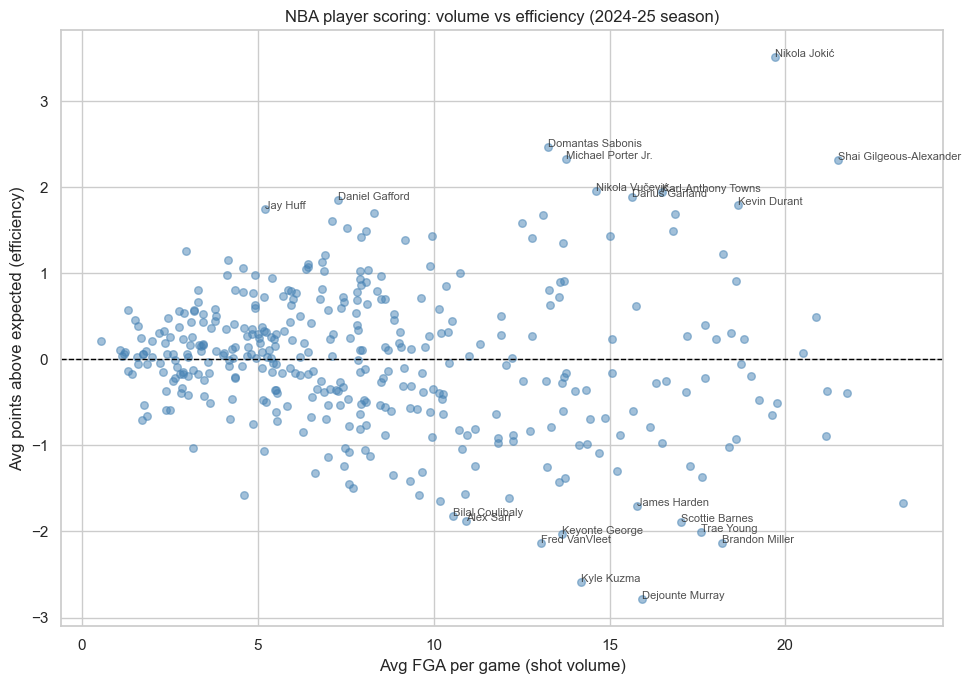

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(per_player["avg_FGA"], per_player["avg_residual"],
           s=30, alpha=0.5, color="steelblue")

# Label the 10 most positive and 10 most negative players
label_pool = pd.concat([per_player.head(10), per_player.tail(10)])
for name, row in label_pool.iterrows():
    ax.annotate(name, (row["avg_FGA"], row["avg_residual"]),
                fontsize=8, alpha=0.8)

ax.axhline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Avg FGA per game (shot volume)")
ax.set_ylabel("Avg points above expected (efficiency)")
ax.set_title("NBA player scoring: volume vs efficiency (2024-25 season)")
plt.tight_layout(); plt.show()

## 8. Sanity check + insight

**What you should see**
- The top of the leaderboard is dominated by **efficient high-scorers** (elite scorers + efficient role players who finish at the rim or hit open threes).
- The bottom is dominated by **high-volume but inefficient** guards/wings — players who take a lot of shots but don't convert.
- Most of the league sits near zero — that's exactly what "average" means.

**The insight worth writing on a portfolio page**
> Using an ML model trained on 16,500 player-games, we built a **league-neutral "expected points" baseline** from shot volume. The residual — how many points a player scored *above* that baseline — gives a principled ranking of scoring efficiency for the 2024-25 season.

## 9. Conclusion

**What we built**
- A clean expected-points model from shot-volume features only.
- Per-game residuals (actual − expected).
- A per-player leaderboard of scoring efficiency.

**Ideas for extending the project**
1. Add **shot location** data (from a second dataset) — rim vs mid-range vs three.
2. Compute residuals **per opponent** — who overperforms specifically against elite defenses?
3. Split by **first half of season vs second half** — identify improvers.
4. Use the residual as a feature for a downstream task (e.g., predicting playoff team wins).
